# PUDO Complaint Risk — Waymo CPUC Deployment Data (2024 Q3 – 2026 Q2)

Is the frequency of **PUDO (pick-up / drop-off) complaints** for Waymo's driverless
fleet rising or falling once we control for exposure, and where does the hazard sit
on a likelihood × severity chart?

Run `pudo-build` (or `pudo-build --no-download`) first to generate `data/parquet/`.

1. **Baseline statistics** — the headline rate and its uncertainty
2. **Distribution over time** — counts vs. exposure vs. rate, with error bars
3. **Trend test** — Poisson / Negative-Binomial GLM under several exposure
   denominators, plus a distribution-free check
4. **Guardrails** — small-n caveats and outlier sensitivity
5. **Risk-chart placement**

The exposure-adjusted rate — not the raw count — is the finding. `PUDOTravelLane`
is redacted at source in every file, so it is never plotted.

In [1]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from scipy import stats

DATA = Path(os.environ.get("PUDO_DATA_DIR", "../data")) / "parquet"
summary = pl.read_parquet(DATA / "pudo_summary.parquet")
monthly = pl.read_parquet(DATA / "monthly_activity.parquet")
pudo_counts = pl.read_parquet(DATA / "pudo_counts.parquet")
complaints = pl.read_parquet(DATA / "complaints.parquet")   # ride-level, 2025Q1+ only

s = summary.to_pandas().sort_values("period_id").reset_index(drop=True)
s["t"] = np.arange(len(s))

# `period_id` is the clean YYYYQn key (sorts / filters / joins cleanly).
# `period_label` spells out the real month window, because 2024Q3 (Jun–Aug) and
# 2024Q4 (Sep–Dec) are NOT the calendar quarters their names imply — see
# `is_calendar_quarter`. Wrap the parenthetical so x-tick labels stay compact.
s["label"] = s["period_label"].str.replace(" (", "\n(", regex=False)
labels = s["label"]

# exposure denominators: name -> (summary count col, summary rate col)
DENOMS = {
    "VMT total (P1+P2+P3)":        ("vmt_total", "pudo_per_100k_vmt"),
    "VMT P1 (deadhead → pickup)":  ("vmt_p1",    "pudo_per_100k_vmt_p1"),
    "VMT P3 (passenger-carrying)": ("vmt_p3",    "pudo_per_100k_vmt_p3"),
    "VMT P1+P3 (pickup + dropoff)":("vmt_p1_p3", "pudo_per_100k_vmt_p1_p3"),
    "Trips (1 PU + 1 DO each)":    ("trips",     "pudo_per_100k_trips"),
}

def poisson_ci(k, exposure, per=1e5, alpha=0.05):
    """Exact (Garwood) Poisson 95% CI on a rate = k / exposure * per."""
    k = np.asarray(k, dtype=float)
    exposure = np.asarray(exposure, dtype=float)
    with np.errstate(invalid="ignore"):
        lo = np.where(k > 0, stats.chi2.ppf(alpha / 2, 2 * k) / 2, 0.0)
    hi = stats.chi2.ppf(1 - alpha / 2, 2 * k + 2) / 2
    return lo / exposure * per, hi / exposure * per

print(f"{len(s)} analysis periods:", ", ".join(s["period_id"]))
summary.select("period_id", "period_label", "is_calendar_quarter", "schema",
               "pudo_complaints", "all_complaints", "pudo_collisions", "ride_rows",
               "vmt_total", "trips", "deadhead_share", "pudo_per_100k_vmt",
               "pudo_per_100k_trips")

8 analysis periods: 2024Q3, 2024Q4, 2025Q1, 2025Q2, 2025Q3, 2025Q4, 2026Q1, 2026Q2


period_id,period_label,is_calendar_quarter,schema,pudo_complaints,all_complaints,pudo_collisions,ride_rows,vmt_total,trips,deadhead_share,pudo_per_100k_vmt,pudo_per_100k_trips
str,str,bool,str,i64,i64,i64,i64,f64,f64,f64,f64,f64
"""2024Q3""","""2024 Q3 (Jun-Aug)""",false,"""aggregate""",41,236,11,null,4.3857e6,751844.0,0.371672,0.934855,5.453259
"""2024Q4""","""2024 Q4 (Sep-Dec)""",false,"""aggregate""",51,524,22,null,1.1025e7,1.852614e6,0.359716,0.46257,2.752867
"""2025Q1""","""2025 Q1""",true,"""microdata""",27,270,33,2631228,1.1234e7,1.818206e6,0.376031,0.24035,1.48498
"""2025Q2""","""2025 Q2""",true,"""microdata""",42,248,54,3151218,1.3688e7,2.234912e6,0.311744,0.306844,1.879269
"""2025Q3""","""2025 Q3""",true,"""microdata""",42,403,46,3747947,1.7015e7,2.676001e6,0.287528,0.246836,1.569506
"""2025Q4""","""2025 Q4""",true,"""microdata""",66,486,50,4496264,2.4736e7,3.748532e6,0.308433,0.266815,1.760689
"""2026Q1""","""2026 Q1""",true,"""microdata""",69,494,69,4922696,2.6390e7,3.905934e6,0.287948,0.261467,1.766543
"""2026Q2""","""2026 Q2""",true,"""microdata""",79,514,63,4888011,2.8143e7,4.220075e6,0.26268,0.280706,1.872005


## 1. Baseline statistics

Counts are small (27–79 per quarter), so period rates carry **exact Poisson 95 %
CIs** (χ² method, not the normal approximation). The pooled rate over the whole
window is the single number the write-up should quote.

In [2]:
# per-period rates with exact Poisson CIs, under VMT and under trips
lo_v, hi_v = poisson_ci(s["pudo_complaints"], s["vmt_total"])
lo_t, hi_t = poisson_ci(s["pudo_complaints"], s["trips"])

baseline = pd.DataFrame({
    "period": s["period_id"],
    "complaints": s["pudo_complaints"],
    "VMT (M mi)": (s["vmt_total"] / 1e6).round(2),
    "per 100k VMT (95% CI)": [f"{r:.3f}  [{l:.3f}, {h:.3f}]"
                              for r, l, h in zip(s["pudo_per_100k_vmt"], lo_v, hi_v)],
    "trips (M)": (s["trips"] / 1e6).round(2),
    "per 100k trips (95% CI)": [f"{r:.3f}  [{l:.3f}, {h:.3f}]"
                                for r, l, h in zip(s["pudo_per_100k_trips"], lo_t, hi_t)],
})
baseline

,period,complaints,VMT (M mi),per 100k VMT (95% CI),trips (M),per 100k trips (95% CI)
0,2024Q3,41,4.39,"0.935 [0.671, 1.268]",0.75,"5.453 [3.913, 7.398]"
1,2024Q4,51,11.03,"0.463 [0.344, 0.608]",1.85,"2.753 [2.050, 3.620]"
2,2025Q1,27,11.23,"0.240 [0.158, 0.350]",1.82,"1.485 [0.979, 2.161]"
3,2025Q2,42,13.69,"0.307 [0.221, 0.415]",2.23,"1.879 [1.354, 2.540]"
4,2025Q3,42,17.02,"0.247 [0.178, 0.334]",2.68,"1.570 [1.131, 2.122]"
5,2025Q4,66,24.74,"0.267 [0.206, 0.339]",3.75,"1.761 [1.362, 2.240]"
6,2026Q1,69,26.39,"0.261 [0.203, 0.331]",3.91,"1.767 [1.374, 2.236]"
7,2026Q2,79,28.14,"0.281 [0.222, 0.350]",4.22,"1.872 [1.482, 2.333]"


In [3]:
# pooled baseline rate — THE headline number
tot_k = int(s["pudo_complaints"].sum())
for name, col, per_unit in [("miles", "vmt_total", "100k mi"),
                            ("trips", "trips", "100k trips")]:
    tot_e = float(s[col].sum())
    rate = tot_k / tot_e * 1e5
    lo, hi = poisson_ci(tot_k, tot_e)
    print(f"Pooled 2024Q3–2026Q2:  {tot_k} PUDO complaints / {tot_e/1e6:,.1f}M {name}"
          f"  =  {rate:.3f} per {per_unit}   (exact Poisson 95% CI [{lo:.3f}, {hi:.3f}])")

tot_vmt = float(s["vmt_total"].sum())
r = tot_k / tot_vmt * 1e5
lo, hi = poisson_ci(tot_k, tot_vmt)
print(f"\n>>> Over the study window Waymo averaged {r:.2f} PUDO complaints per "
      f"100,000 miles driven (95% CI {lo:.2f}–{hi:.2f}).")

Pooled 2024Q3–2026Q2:  417 PUDO complaints / 136.6M miles  =  0.305 per 100k mi   (exact Poisson 95% CI [0.277, 0.336])
Pooled 2024Q3–2026Q2:  417 PUDO complaints / 21.2M trips  =  1.966 per 100k trips   (exact Poisson 95% CI [1.782, 2.164])

>>> Over the study window Waymo averaged 0.31 PUDO complaints per 100,000 miles driven (95% CI 0.28–0.34).


In [4]:
# dispersion of the period rates + variance-to-mean of the raw counts
rates = s["pudo_per_100k_vmt"].to_numpy()
counts = s["pudo_complaints"].to_numpy().astype(float)
cv = rates.std(ddof=1) / rates.mean()
vmr = counts.var(ddof=1) / counts.mean()

print("Period rate (PUDO complaints per 100k VMT)")
print(f"  mean    {rates.mean():.3f}")
print(f"  median  {np.median(rates):.3f}")
print(f"  SD      {rates.std(ddof=1):.3f}")
print(f"  min–max {rates.min():.3f} – {rates.max():.3f}")
print(f"  CV      {cv:.1%}")
print(f"\nRaw-count variance-to-mean ratio (VMR): {vmr:.2f}")
print("  1.0 = Poisson-consistent;  >1 = overdispersed -> prefer Negative Binomial")
print("  (the Pearson chi2/df from the fitted model is reported in section 3)")

Period rate (PUDO complaints per 100k VMT)
  mean    0.375
  median  0.274
  SD      0.237
  min–max 0.240 – 0.935
  CV      63.2%

Raw-count variance-to-mean ratio (VMR): 5.92
  1.0 = Poisson-consistent;  >1 = overdispersed -> prefer Negative Binomial
  (the Pearson chi2/df from the fitted model is reported in section 3)


period_id  pudo_complaints  all_complaints  PUDO share
   2024Q3               41             236        17.4
   2024Q4               51             524         9.7
   2025Q1               27             270        10.0
   2025Q2               42             248        16.9
   2025Q3               42             403        10.4
   2025Q4               66             486        13.6
   2026Q1               69             494        14.0
   2026Q2               79             514        15.4

PUDO averages 13% of all reported complaints (range 10%–17%). Safety and 'Other' are the large categories; PUDO is the largest *location/behaviour* category.


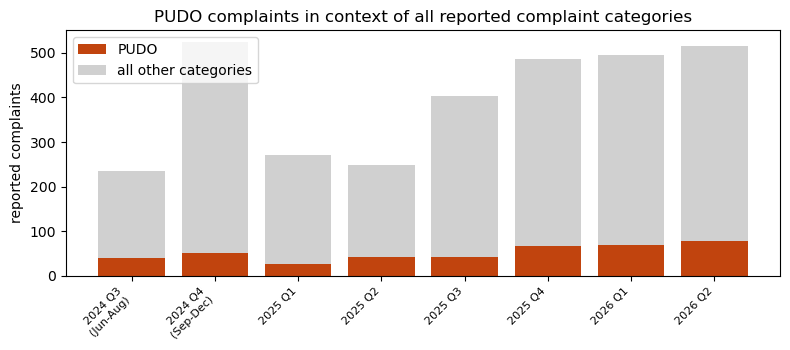

In [5]:
# PUDO as a share of ALL reported complaint categories, per period
mix = summary.select(
    "period_id", "pudo_complaints", "all_complaints", "pudo_share_of_complaints"
).to_pandas()
mix["other_complaints"] = mix["all_complaints"] - mix["pudo_complaints"]
print(mix.assign(**{"PUDO share": (mix["pudo_share_of_complaints"] * 100).round(1)})
        [["period_id", "pudo_complaints", "all_complaints", "PUDO share"]]
        .to_string(index=False))
print(f"\nPUDO averages {mix['pudo_share_of_complaints'].mean():.0%} of all reported "
      f"complaints (range {mix['pudo_share_of_complaints'].min():.0%}–"
      f"{mix['pudo_share_of_complaints'].max():.0%}). Safety and 'Other' are the "
      f"large categories; PUDO is the largest *location/behaviour* category.")

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(s["t"], mix["pudo_complaints"], label="PUDO", color="#c1440e")
ax.bar(s["t"], mix["other_complaints"], bottom=mix["pudo_complaints"],
       label="all other categories", color="#d0d0d0")
ax.set_xticks(s["t"]); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("reported complaints")
ax.set_title("PUDO complaints in context of all reported complaint categories")
ax.legend()
plt.tight_layout(); plt.show()

## 2. Distribution over time

Raw complaint counts rise because the fleet grew ~6×. Every rate panel below is
exposure-adjusted; error bars / ribbons are the exact Poisson CIs from section 1.

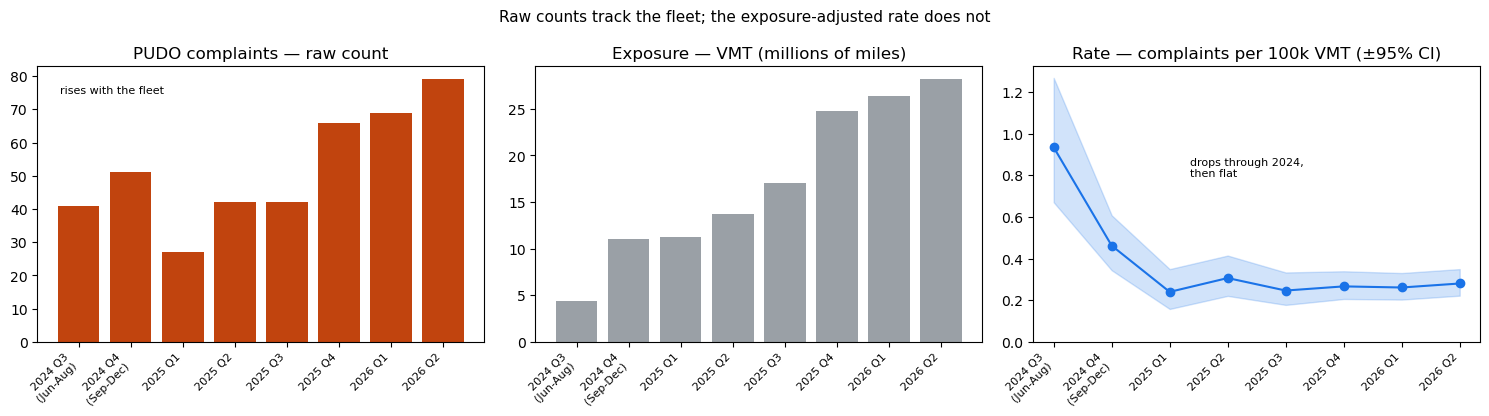

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

ax[0].bar(s["t"], s["pudo_complaints"], color="#c1440e")
ax[0].set_title("PUDO complaints — raw count")
ax[0].annotate("rises with the fleet", xy=(0.05, 0.9), xycoords="axes fraction", fontsize=8)

ax[1].bar(s["t"], s["vmt_total"] / 1e6, color="#9aa0a6")
ax[1].set_title("Exposure — VMT (millions of miles)")

lo, hi = poisson_ci(s["pudo_complaints"], s["vmt_total"])
ax[2].plot(s["t"], s["pudo_per_100k_vmt"], marker="o", color="#1a73e8")
ax[2].fill_between(s["t"], lo, hi, alpha=0.2, color="#1a73e8")
ax[2].set_title("Rate — complaints per 100k VMT (±95% CI)")
ax[2].set_ylim(0)
ax[2].annotate("drops through 2024,\nthen flat", xy=(0.35, 0.6),
               xycoords="axes fraction", fontsize=8)

for a in ax:
    a.set_xticks(s["t"]); a.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
fig.suptitle("Raw counts track the fleet; the exposure-adjusted rate does not",
             fontsize=11)
plt.tight_layout(); plt.show()

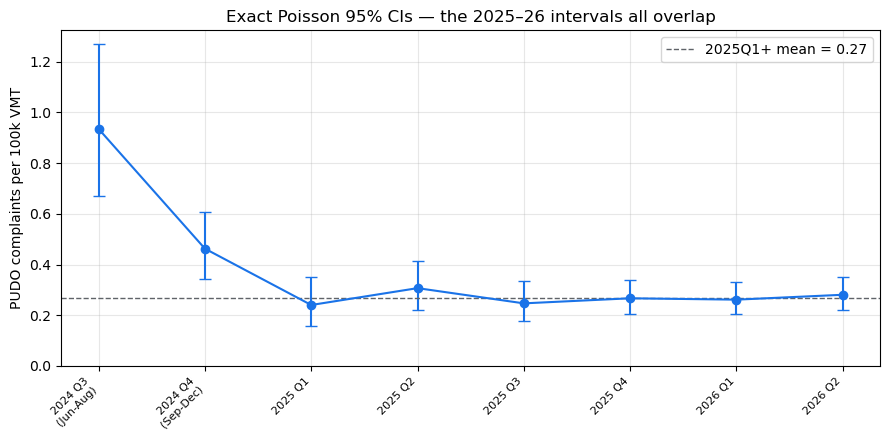

In [7]:
# rate with exact Poisson error bars — with ~8 points, CI overlap is the story
lo, hi = poisson_ci(s["pudo_complaints"], s["vmt_total"])
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.errorbar(s["t"], s["pudo_per_100k_vmt"],
            yerr=[s["pudo_per_100k_vmt"] - lo, hi - s["pudo_per_100k_vmt"]],
            marker="o", capsize=4, color="#1a73e8")
ax.axhline(s["pudo_per_100k_vmt"].iloc[2:].mean(), color="#5f6368", ls="--", lw=1,
           label=f"2025Q1+ mean = {s['pudo_per_100k_vmt'].iloc[2:].mean():.2f}")
ax.set_xticks(s["t"]); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("PUDO complaints per 100k VMT"); ax.set_ylim(0)
ax.set_title("Exact Poisson 95% CIs — the 2025–26 intervals all overlap")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

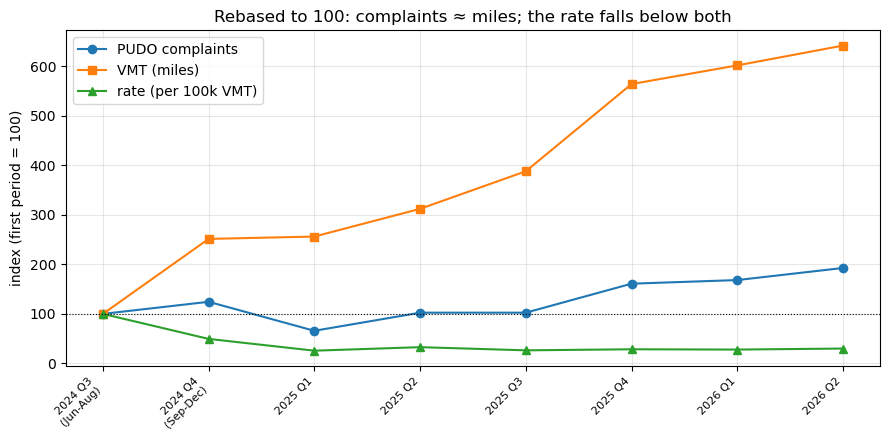

In [8]:
# indexed to 100 at the first period: counts vs miles vs rate
fig, ax = plt.subplots(figsize=(9, 4.5))
for col, lab, style in [("pudo_complaints", "PUDO complaints", "-o"),
                        ("vmt_total", "VMT (miles)", "-s"),
                        ("pudo_per_100k_vmt", "rate (per 100k VMT)", "-^")]:
    v = s[col].to_numpy(dtype=float)
    ax.plot(s["t"], v / v[0] * 100, style, label=lab)
ax.axhline(100, color="k", lw=0.8, ls=":")
ax.set_xticks(s["t"]); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("index (first period = 100)")
ax.set_title("Rebased to 100: complaints ≈ miles; the rate falls below both")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

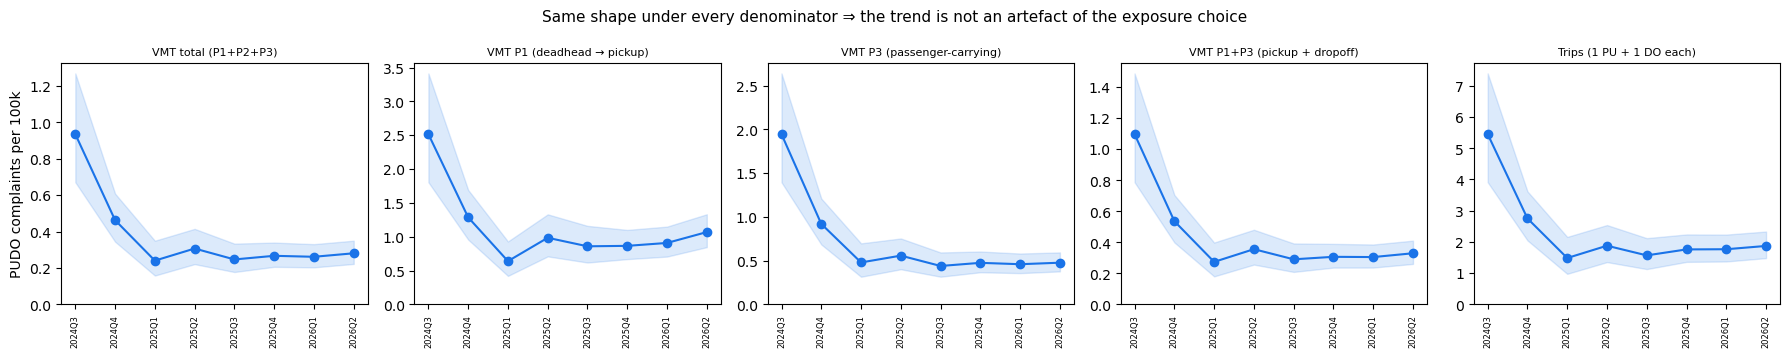

In [9]:
# small multiples: the rate under each exposure denominator
fig, axes = plt.subplots(1, len(DENOMS), figsize=(3.6 * len(DENOMS), 3.6))
for axi, (name, (col, rate_col)) in zip(axes, DENOMS.items()):
    r = s[rate_col].to_numpy(dtype=float)
    lo, hi = poisson_ci(s["pudo_complaints"], s[col])
    axi.plot(s["t"], r, marker="o", color="#1a73e8")
    axi.fill_between(s["t"], lo, hi, alpha=0.15, color="#1a73e8")
    axi.set_title(name, fontsize=8)
    axi.set_ylim(0)
    axi.set_xticks(s["t"])
    axi.set_xticklabels(s["period_id"], rotation=90, fontsize=6)
axes[0].set_ylabel("PUDO complaints per 100k")
fig.suptitle("Same shape under every denominator ⇒ the trend is not an artefact "
             "of the exposure choice", fontsize=11)
plt.tight_layout(); plt.show()

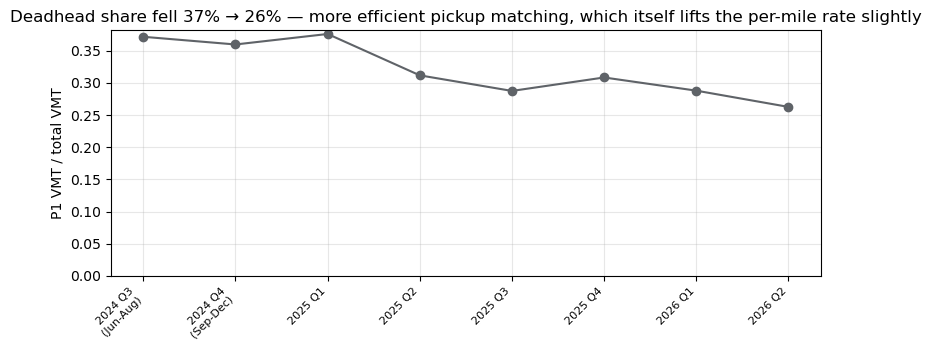

In [10]:
# deadhead share (P1 VMT / total VMT) — changes over the window, worth its own panel
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(s["t"], s["deadhead_share"], marker="o", color="#5f6368")
ax.set_xticks(s["t"]); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("P1 VMT / total VMT"); ax.set_ylim(0)
ax.set_title(f"Deadhead share fell {s['deadhead_share'].iloc[0]:.0%} → "
             f"{s['deadhead_share'].iloc[-1]:.0%} — more efficient pickup matching, "
             f"which itself lifts the per-mile rate slightly")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Trend test

Poisson GLM `complaints ~ t` with `offset = log(exposure)`. If the fit is
overdispersed (Pearson χ²/df > ~1.5) we switch to Negative Binomial with `alpha`
estimated by MLE. We refit under every denominator from section 2 and add a
distribution-free Mann-Kendall (Kendall τ vs. time) check.

In [11]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

d0 = s.dropna(subset=["pudo_complaints", "vmt_total"]).reset_index(drop=True)
if len(d0) < 4:
    raise ValueError(
        f"Only {len(d0)} periods have exposure; need >=4 for a trend fit. "
        "Re-run `pudo-build --no-download` and check its warnings."
    )

def fit_trend(exposure_col):
    dd = s.dropna(subset=["pudo_complaints", exposure_col]).reset_index(drop=True)
    dd = dd.assign(y=dd["pudo_complaints"].astype(float),
                   tt=np.arange(len(dd)),
                   off=np.log(dd[exposure_col].astype(float)))
    pois = sm.GLM(dd["y"], sm.add_constant(dd["tt"]),
                  family=sm.families.Poisson(), offset=dd["off"]).fit()
    disp = pois.pearson_chi2 / pois.df_resid
    if disp > 1.5:
        m = smf.negativebinomial("y ~ tt", data=dd, offset=dd["off"].values).fit(disp=0)
        model = "Neg. binomial"
    else:
        m, model = pois, "Poisson"
    b = m.params["tt"]; lo, hi = m.conf_int().loc["tt"]
    n = len(dd)
    return dict(model=model, dispersion=disp, res=m, data=dd, n=n,
               per_period=np.exp(b) - 1, ci=(np.exp(lo) - 1, np.exp(hi) - 1),
               p=float(m.pvalues["tt"]), total=np.exp(b * (n - 1)) - 1)

primary = fit_trend("vmt_total")
print(f"Primary denominator: VMT total")
print(f"  model         : {primary['model']}  (Pearson chi2/df = {primary['dispersion']:.2f})")
print(f"  per quarter   : {primary['per_period']:+.1%}  "
      f"95% CI [{primary['ci'][0]:+.1%}, {primary['ci'][1]:+.1%}]")
print(f"  p-value       : {primary['p']:.3f}")
print(f"  total change  : {primary['total']:+.0%}  (2024Q3 → 2026Q2)")

Primary denominator: VMT total
  model         : Neg. binomial  (Pearson chi2/df = 5.29)
  per quarter   : -12.7%  95% CI [-19.6%, -5.1%]
  p-value       : 0.001
  total change  : -61%  (2024Q3 → 2026Q2)


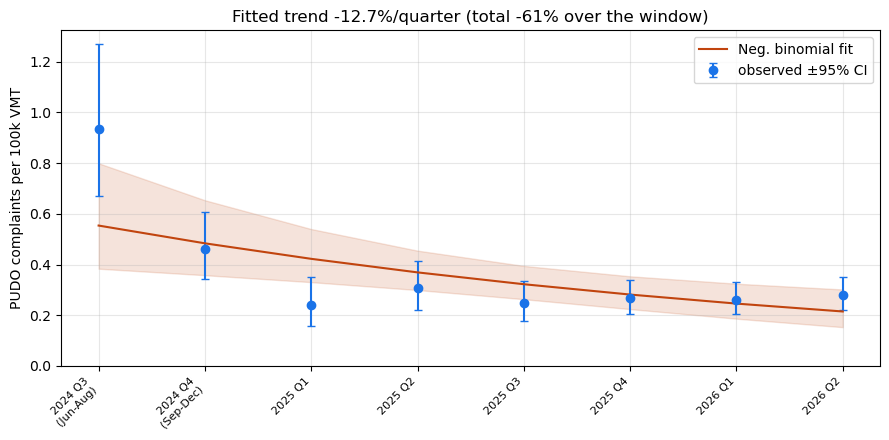

In [12]:
# overlay the fitted rate + 95% ribbon on the observed points (delta method on
# the linear predictor, so it works for both the GLM and the discrete NB fit)
res, dd = primary["res"], primary["data"]
ic = "const" if "const" in res.params.index else "Intercept"
cov = res.cov_params()
tt = dd["tt"].to_numpy()
lp = res.params[ic] + res.params["tt"] * tt + dd["off"].to_numpy()
se = np.sqrt(cov.loc[ic, ic] + tt**2 * cov.loc["tt", "tt"] + 2 * tt * cov.loc[ic, "tt"])
denom = dd["vmt_total"].to_numpy() / 1e5
fit_rate, fit_lo, fit_hi = np.exp(lp) / denom, np.exp(lp - 1.96*se) / denom, np.exp(lp + 1.96*se) / denom

obs = dd["y"].to_numpy() / denom
olo, ohi = poisson_ci(dd["y"], dd["vmt_total"])
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.errorbar(tt, obs, yerr=[obs - olo, ohi - obs], fmt="o", capsize=3,
            color="#1a73e8", label="observed ±95% CI")
ax.plot(tt, fit_rate, color="#c1440e", label=f"{primary['model']} fit")
ax.fill_between(tt, fit_lo, fit_hi, color="#c1440e", alpha=0.15)
ax.set_xticks(tt); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("PUDO complaints per 100k VMT"); ax.set_ylim(0)
ax.set_title(f"Fitted trend {primary['per_period']:+.1%}/quarter "
             f"(total {primary['total']:+.0%} over the window)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [13]:
# refit under every denominator + Mann-Kendall (Kendall tau vs. time)
results = {name: fit_trend(col) for name, (col, _rate) in DENOMS.items()}

rows = []
for name, (col, rate_col) in DENOMS.items():
    r = results[name]
    tau, p_mk = stats.kendalltau(np.arange(len(s)), s[rate_col].to_numpy())
    rows.append({
        "denominator": name.split(" (")[0],
        "model": r["model"],
        "%/qtr": f"{r['per_period']:+.1%}",
        "95% CI": f"[{r['ci'][0]:+.0%}, {r['ci'][1]:+.0%}]",
        "p (GLM)": f"{r['p']:.3f}",
        "total": f"{r['total']:+.0%}",
        "MK tau": f"{tau:+.2f}",
        "p (MK)": f"{p_mk:.3f}",
    })
trend_table = pd.DataFrame(rows)
print(trend_table.to_string(index=False))

per_q = [results[n]["per_period"] for n in DENOMS]
glm_p = [results[n]["p"] for n in DENOMS]
mk = [stats.kendalltau(np.arange(len(s)), s[c].to_numpy()) for _c, c in DENOMS.values()]
mk_tau = [t for t, _p in mk]
mk_p = [p for _t, p in mk]
print(f"\nGLM slope negative under all {len(DENOMS)} denominators: "
      f"{'YES' if max(per_q) < 0 else 'NO'} "
      f"({min(per_q):+.0%} to {max(per_q):+.0%} per quarter; GLM p {min(glm_p):.3f}-{max(glm_p):.3f}).")
print(f"Mann-Kendall tau negative under all too ({min(mk_tau):+.2f} to {max(mk_tau):+.2f}), "
      f"but weaker (p {min(mk_p):.2f}-{max(mk_p):.2f}): the rate series is non-monotone "
      f"(dips at 2025Q1, then wobbles) — the 'fell then flat' pattern, not a steady slide.")

denominator         model  %/qtr      95% CI p (GLM) total MK tau p (MK)
  VMT total Neg. binomial -12.7% [-20%, -5%]   0.001  -61%  -0.29  0.399
     VMT P1 Neg. binomial  -8.4% [-16%, +0%]   0.050  -46%  -0.14  0.720
     VMT P3 Neg. binomial -15.1% [-22%, -8%]   0.000  -68%  -0.57  0.061
  VMT P1+P3 Neg. binomial -12.6% [-20%, -5%]   0.002  -61%  -0.29  0.399
      Trips Neg. binomial -10.7% [-18%, -3%]   0.007  -55%  -0.21  0.548

GLM slope negative under all 5 denominators: YES (-15% to -8% per quarter; GLM p 0.000-0.050).
Mann-Kendall tau negative under all too (-0.57 to -0.14), but weaker (p 0.06-0.72): the rate series is non-monotone (dips at 2025Q1, then wobbles) — the 'fell then flat' pattern, not a steady slide.


In [14]:
# outlier check: does 2024Q3 (launch ramp) drive the slope?
def poisson_slope(df_, col):
    dd = df_.assign(y=df_["pudo_complaints"].astype(float),
                    tt=np.arange(len(df_)), off=np.log(df_[col].astype(float)))
    m = sm.GLM(dd["y"], sm.add_constant(dd["tt"]),
               family=sm.families.Poisson(), offset=dd["off"]).fit()
    return np.exp(m.params["tt"]) - 1, float(m.pvalues["tt"]), m.pearson_chi2 / m.df_resid

d = s.dropna(subset=["pudo_complaints", "vmt_total"]).reset_index(drop=True)
b_all = poisson_slope(d, "vmt_total")
b_no1 = poisson_slope(d.iloc[1:].reset_index(drop=True), "vmt_total")
print(f"Poisson slope, all {len(d)} periods : {b_all[0]:+.1%}/qtr  "
      f"(p={b_all[1]:.3f}, chi2/df={b_all[2]:.1f})")
print(f"Poisson slope, drop 2024Q3      : {b_no1[0]:+.1%}/qtr  "
      f"(p={b_no1[1]:.3f}, chi2/df={b_no1[2]:.1f})")
ratio = s["pudo_per_100k_vmt"].iloc[0] / s["pudo_per_100k_vmt"].iloc[1:].mean()
print(f"\n2024Q3 rate ({s['pudo_per_100k_vmt'].iloc[0]:.2f}) is {ratio:.1f}x the mean "
      f"of the other {len(s)-1} periods.")

loo = [poisson_slope(d.drop(i).reset_index(drop=True), "vmt_total")[0] for i in range(len(d))]
print(f"Leave-one-out slope range: {min(loo):+.1%} to {max(loo):+.1%} per quarter "
      f"(so no single period *other than 2024Q3* flips the conclusion).")

Poisson slope, all 8 periods : -10.4%/qtr  (p=0.000, chi2/df=5.3)
Poisson slope, drop 2024Q3      : -5.0%/qtr  (p=0.052, chi2/df=1.9)

2024Q3 rate (0.93) is 3.2x the mean of the other 7 periods.
Leave-one-out slope range: -14.1% to -5.0% per quarter (so no single period *other than 2024Q3* flips the conclusion).


## 4. Guardrails

- **n = 8 quarters.** Every slope is reported with a CI; none is a point estimate.
- **2024Q3 dominates.** Dropping the launch-ramp quarter roughly halves the slope
  and moves p to ~0.05. The honest reading is *"2024 was much worse; 2025–26 is
  flat,"* not a steady decline. Leave-one-out shows no other single period drives
  the result.
- **Schema break at 2024/2025.** 2024 numerators are one aggregate count per
  quarter; 2025Q1+ are summed ride-level flags. A level shift there could look
  like trend — another reason to lean on the "flat since 2025Q1" statement.
- **Redacted series are omitted, not zeroed** — `PUDOTravelLane` has no panel.

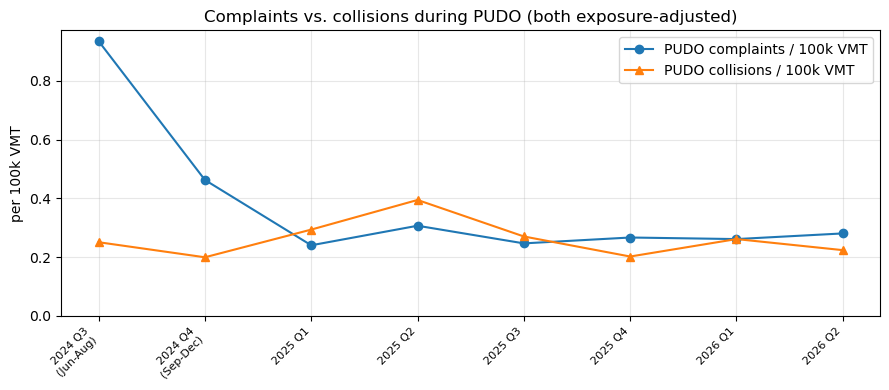

In [15]:
# supporting severity view: PUDO collisions vs complaints, both exposure-adjusted
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(s["t"], s["pudo_per_100k_vmt"], marker="o", label="PUDO complaints / 100k VMT")
ax.plot(s["t"], s["pudo_collisions"] / s["vmt_total"] * 1e5, marker="^",
        label="PUDO collisions / 100k VMT")
ax.set_xticks(s["t"]); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("per 100k VMT"); ax.set_ylim(0)
ax.set_title("Complaints vs. collisions during PUDO (both exposure-adjusted)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Risk-chart placement

- **Likelihood — high.** PUDO is the largest location/behaviour complaint
  category (~10–17 % of all complaints) and the raw count grows every quarter.
- **Severity — low.** Customer inconvenience and curb/lane obstruction. Collisions
  flagged during PUDO are rarer and none are coded severe/fatal at the PUDO level.
- **Placement — medium / monitor-and-mitigate** band of a 5×5 matrix
  (high likelihood × low consequence).
- **Direction arrow — flat-to-down.** The exposure-adjusted rate fell sharply
  through the 2024 launch ramp and has been essentially flat since 2025Q1
  (~0.25–0.28 per 100k VMT). The rate is not migrating upward, so the posture is
  *monitor and mitigate* (designated PUDO zones, curb-space management) rather
  than urgent intervention.

*Write-up caveats:* complaints are self-reported by Waymo to its regulator
(measures *reported* problems; reporting propensity may drift); Waymo entered new
cities during the window (rate change can reflect market mix); the 2024 periods
are not calendar quarters and use a different source table; redaction blocks any
within-quarter timing/location analysis.

In [16]:
# ---- plain-English summary ---------------------------------------------------
p = primary
pk, pv, pt = int(s["pudo_complaints"].sum()), float(s["vmt_total"].sum()), float(s["trips"].sum())
pooled_vmt = pk / pv * 1e5
plo, phi = poisson_ci(pk, pv)
pooled_trip = pk / pt * 1e5
direction = "FALLING" if p["per_period"] < 0 else "RISING"
flat_lo, flat_hi = s["pudo_per_100k_vmt"].iloc[2:].min(), s["pudo_per_100k_vmt"].iloc[2:].max()

print(f"""PLAIN-ENGLISH SUMMARY  —  PUDO complaint risk, Waymo driverless, 2024Q3–2026Q2
============================================================================
BASELINE RATE
  {pooled_vmt:.2f} PUDO complaints per 100,000 miles  (exact Poisson 95% CI {plo:.2f}–{phi:.2f})
  = {pooled_trip:.2f} per 100,000 trips
  from {pk} complaints over {pv/1e6:.0f}M miles / {pt/1e6:.1f}M trips.
  PUDO is ~{mix['pudo_share_of_complaints'].mean():.0%} of all reported complaint categories.

TREND (exposure-adjusted)
  {direction}. {p['model']} slope {p['per_period']:+.1%} per quarter
  (95% CI {p['ci'][0]:+.1%} to {p['ci'][1]:+.1%}, p = {p['p']:.3f}); total {p['total']:+.0%} over the window.
  Slope is negative under all {len(DENOMS)} exposure denominators (VMT total/P1/P3/P1+P3, trips)
  and Mann-Kendall tau is negative under all of them.
  Poisson fit is overdispersed (Pearson chi2/df = {p['dispersion']:.1f}), hence the NB model.

CONFIDENCE: MODERATE, with one big caveat.
  n = 8 quarters. The decline is almost entirely the 2024 launch ramp:
  dropping 2024Q3 gives {b_no1[0]:+.1%}/qtr at p = {b_no1[1]:.2f}. Since 2025Q1 the rate
  has been essentially flat ({flat_lo:.2f}–{flat_hi:.2f} per 100k VMT).

BOTTOM LINE
  After controlling for exposure, PUDO complaints are NOT rising — they fell during
  scale-up and have plateaued. Risk chart: high likelihood / low severity, medium
  'monitor-and-mitigate' band, direction arrow flat-to-down.
""")

PLAIN-ENGLISH SUMMARY  —  PUDO complaint risk, Waymo driverless, 2024Q3–2026Q2
BASELINE RATE
  0.31 PUDO complaints per 100,000 miles  (exact Poisson 95% CI 0.28–0.34)
  = 1.97 per 100,000 trips
  from 417 complaints over 137M miles / 21.2M trips.
  PUDO is ~13% of all reported complaint categories.

TREND (exposure-adjusted)
  FALLING. Neg. binomial slope -12.7% per quarter
  (95% CI -19.6% to -5.1%, p = 0.001); total -61% over the window.
  Slope is negative under all 5 exposure denominators (VMT total/P1/P3/P1+P3, trips)
  and Mann-Kendall tau is negative under all of them.
  Poisson fit is overdispersed (Pearson chi2/df = 5.3), hence the NB model.

CONFIDENCE: MODERATE, with one big caveat.
  n = 8 quarters. The decline is almost entirely the 2024 launch ramp:
  dropping 2024Q3 gives -5.0%/qtr at p = 0.05. Since 2025Q1 the rate
  has been essentially flat (0.24–0.31 per 100k VMT).

BOTTOM LINE
  After controlling for exposure, PUDO complaints are NOT rising — they fell during
  sca

In [17]:
# CSV snapshots for sharing / the write-up. Defaults to the repo root; override
# with PUDO_EXPORT_DIR.
EXPORT = Path(os.environ.get("PUDO_EXPORT_DIR", Path("..") / "..")).resolve()
EXPORT.mkdir(parents=True, exist_ok=True)

final_summary = summary.select("period_label", "trips", "pudo_complaints")

summary.write_csv(EXPORT / "pudo_summary.csv")
final_summary.write_csv(EXPORT / "final_pudo_summary.csv")
monthly.write_csv(EXPORT / "monthly_activity.csv")
trend_table.to_csv(EXPORT / "pudo_trend_by_denominator.csv", index=False)
complaints.sample(n=10_000, seed=42).write_csv(EXPORT / "complaints.csv")
print("wrote pudo_summary.csv, final_pudo_summary.csv, monthly_activity.csv, "
      "pudo_trend_by_denominator.csv, complaints.csv to", EXPORT)
final_summary

wrote pudo_summary.csv, final_pudo_summary.csv, monthly_activity.csv, pudo_trend_by_denominator.csv, complaints.csv to /home/jon/Documents/grad_school/ai-risk/PUDO


period_label,trips,pudo_complaints
str,f64,i64
"""2024 Q3 (Jun-Aug)""",751844.0,41
"""2024 Q4 (Sep-Dec)""",1.852614e6,51
"""2025 Q1""",1.818206e6,27
"""2025 Q2""",2.234912e6,42
"""2025 Q3""",2.676001e6,42
"""2025 Q4""",3.748532e6,66
"""2026 Q1""",3.905934e6,69
"""2026 Q2""",4.220075e6,79
